# Rubin ToO Workshop Tutorial: Simulating One Kilonova

This notebook is a hands-on workshop tutorial for building a small Rubin target-of-opportunity simulation around one gravitational-wave superevent.

By the end, you will be able to:

- load an OpSim visit table for a candidate event,
- select visits near an injected sky position,
- configure a Bulla BNS kilonova model,
- simulate Rubin observations with `lightcurvelynx`, `redback`, the Bulla BNS model, and a five-sigma-depth noise model,
- save workshop-ready observation tables, truth curves, and a diagnostic plot,
- compare how the result changes when the same event is moved farther away.



## 1. Setup

Keep the data files in the same folder as this notebook. The paths below are relative to the notebook location so the tutorial works after moving or cloning the folder.


In [1]:
from pathlib import Path
import logging
import os
import time

# Redback imports Numba-decorated helper functions at import time. Disabling JIT
# avoids workshop-machine cache issues while keeping this tutorial deterministic.
os.environ.setdefault("NUMBA_DISABLE_JIT", "1")
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib-cache"))

import astropy.units as u
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord
from astropy.cosmology import FlatLambdaCDM, z_at_value
from IPython.display import Image, display

from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.models.redback_models import RedbackWrapperModel
from lightcurvelynx.obstable.ztf_obstable import ZTFObsTable
from lightcurvelynx.simulate import simulate_lightcurves
from lightcurvelynx.noise_models.base_noise_models import FiveSigmaDepthNoiseModel
from redback.transient_models.kilonova_models import bulla_bns_kilonova

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()

DATA_DIR = NOTEBOOK_DIR
OUTDIR = NOTEBOOK_DIR / "outputs"
OUTDIR.mkdir(exist_ok=True)

mpl.rcParams.update({
    "axes.grid": False,
    "figure.figsize": (13, 6),
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "text.usetex": False,
})
logging.getLogger("lightcurvelynx").setLevel(logging.WARNING)

print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Output directory:   {OUTDIR}")


No module named 'lalsimulation'
lalsimulation is not installed. Some EOS based models will not work. Please use bilby eos or pass your own EOS generation class to the model
swifttools not available. You will not be able to download Swift afterglow data via API.
09:14 bilby INFO    : Running bilby version: 2.8.0
09:14 redback INFO    : Running redback version: 1.16.0


Notebook directory: /Users/np699/Downloads/RubinToOworkshop/2026_Berkeley/Rubin_ToO_workshop
Output directory:   /Users/np699/Downloads/RubinToOworkshop/2026_Berkeley/Rubin_ToO_workshop/outputs


## 2. Inspect the Workshop Data

The main input is an OpSim-style HDF5 table of planned Rubin visits. 


In [2]:
superevent = "S251112cm"
opsim_path = DATA_DIR / f"{superevent}_obs_vanilla.h5"

if not opsim_path.exists():
    raise FileNotFoundError(
        f"Could not find {opsim_path.name}. Keep the HDF5 file next to this notebook."
    )

visit_df = pd.read_hdf(opsim_path)

print(f"Loaded {len(visit_df):,} visits from {opsim_path.name}")
print(f"Columns: {', '.join(visit_df.columns)}")
display(visit_df.head())


Loaded 2,701 visits from S251112cm_obs_vanilla.h5
Columns: ID, RA, dec, mjd, flush_by_mjd, exptime, band, filter, rotSkyPos, rotSkyPos_desired, nexp, airmass, FWHM_500, FWHMeff, FWHM_geometric, skybrightness, night, slewtime, visittime, slewdist, fivesigmadepth, alt, az, pa, pseudo_pa, clouds, moonAlt, sunAlt, scheduler_note, target_name, target_id, lmst, rotTelPos, rotTelPos_backup, moonAz, sunAz, sunRA, sunDec, moonRA, moonDec, moonDist, solarElong, moonPhase, cummTelAz, observation_reason, science_program, cloud_extinction, note


,ID,RA,dec,mjd,flush_by_mjd,exptime,band,filter,rotSkyPos,rotSkyPos_desired,...,moonRA,moonDec,moonDist,solarElong,moonPhase,cummTelAz,observation_reason,science_program,cloud_extinction,note
0,0,6.144020,-0.505590,60991.201263,60993.000000,30.0,g,g_6,0.574571,0.0,...,2.502671,0.307461,2.643415,1.905716,49.825323,-1.831099,too_GW_case_B_C_0_i0,BLOCK-407,0.0,"ToO, GW_case_B_C, g, 0, i0, 770"
1,1,6.147241,-0.511930,60991.201721,60993.083333,30.0,g,g_6,0.571988,0.0,...,2.502772,0.307432,2.638913,1.904478,49.822376,-1.837654,too_GW_case_B_C_0_i1,BLOCK-407,0.0,"ToO, GW_case_B_C, g, 0, i1, 3326"
2,2,6.157866,-0.519252,60991.202184,60993.083333,30.0,g,g_6,0.564274,0.0,...,2.502874,0.307402,2.627956,1.907937,49.819407,-1.843072,too_GW_case_B_C_0_i1,BLOCK-407,0.0,"ToO, GW_case_B_C, g, 0, i1, 3332"
3,3,6.162737,-0.534476,60991.202650,60993.166667,30.0,g,g_6,0.552177,0.0,...,2.502977,0.307373,2.619251,1.902645,49.816412,-1.860110,too_GW_case_B_C_0_i2,BLOCK-407,0.0,"ToO, GW_case_B_C, g, 0, i2, 5909"
4,4,6.181817,-0.544958,60991.203118,60993.000000,30.0,g,g_6,0.538786,0.0,...,2.503079,0.307343,2.600444,1.909818,49.813415,-1.867339,too_GW_case_B_C_0_i0,BLOCK-407,0.0,"ToO, GW_case_B_C, g, 0, i0, 787"


## 3. Choose Event and Simulation Settings

These values are intentionally grouped in one cell so workshop participants can see the assumptions and rerun the tutorial with small changes.


In [3]:
# Event sky position. Values are in radians because the source came from a simulation.
INJ_RA = 0.0
INJ_DEC = -0.52

# Kilonova model parameters.
MEJ_DYN = 0.0134
MEJ_DISK = 0.0897
PHI = 45
COSTHETA_OBS = 1.0

# Search and detection settings.
FIXED_T0 = 60991.20126347534
MIN_DETECTIONS = 0
EVENT_TIME_LIMIT_SEC = 180.0
MAX_ATTEMPTS = 999999
SNR_CUT = 5.0
WINDOW_DAYS = 14.0
MASK_RADIUS_DEG = 1.75

# Plot and truth-table settings.
DT_TRUE = 0.1
NSIGMA_LIM = 5.0
SHIFT_SEARCH_MAX = 10.0
SHIFT_SEARCH_N = 401
RNG_SEED = 12345

cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
passband_group = PassbandGroup.from_preset("LSST")
BANDS_LETTERS = list("ugrizy")
BAND_WAVELENGTH_A = {
    "u": 3671.0,
    "g": 4827.0,
    "r": 6223.0,
    "i": 7546.0,
    "z": 8691.0,
    "y": 9711.0,
}
C_A_PER_DAY = 2.59020683712e23

COLORMAP = {
    "u": "blue",
    "g": "green",
    "r": "red",
    "i": "magenta",
    "z": "purple",
    "y": "gray",
}

print(f"Superevent: {superevent}")
print(f"Sky mask radius: {MASK_RADIUS_DEG} deg")
print(f"Detection threshold: SNR >= {SNR_CUT}")


Superevent: S251112cm
Sky mask radius: 1.75 deg
Detection threshold: SNR >= 5.0


## 4. Helper Functions

These functions keep the workshop cells short. They do four jobs:

1. convert fluxes into AB magnitudes,
2. count detections in the post-trigger window,
3. make the selected Rubin visit table compatible with `lightcurvelynx`,
4. save observation tables, truth curves, and plots.


In [4]:
def safe_float(x, default=np.nan):
    try:
        return float(x)
    except Exception:
        return default


def flux_njy_to_abmag(flux_njy):
    flux_njy = np.asarray(flux_njy, dtype=float)
    return 31.4 - 2.5 * np.log10(np.clip(flux_njy, 1e-30, np.inf))


def magerr_from_flux(flux_njy, fluxerr_njy):
    flux_njy = np.asarray(flux_njy, dtype=float)
    fluxerr_njy = np.asarray(fluxerr_njy, dtype=float)
    flux_njy = np.clip(flux_njy, 1e-30, np.inf)
    return np.abs(1.086 * fluxerr_njy / flux_njy)


def normalize_filter_letter(filt):
    f = str(filt).strip().lower()
    if f.startswith("lsst"):
        f = f[-1]
    if f in BANDS_LETTERS:
        return f
    if len(f) > 0 and f[-1] in BANDS_LETTERS:
        return f[-1]
    raise ValueError(f"Unrecognized filter label: {filt}")


def get_row_t0(row, lc_df):
    t0_true = None
    for key in ["t0", "trigger_mjd", "merger_mjd", "t0_mjd", "t0_injected"]:
        if key in row.index:
            t0_true = safe_float(row[key], default=None)
            if t0_true is not None and np.isfinite(t0_true):
                break
            t0_true = None

    t0_first_obs = float(lc_df["mjd"].min())
    t0_used = float(t0_true) if t0_true is not None else t0_first_obs
    return t0_true, t0_used


def make_model_parameters(distance_mpc):
    redshift = z_at_value(cosmo.luminosity_distance, distance_mpc * u.Mpc).value
    return {
        "redshift": float(redshift),
        "mej_dyn": float(MEJ_DYN),
        "mej_disk": float(MEJ_DISK),
        "phi": float(PHI),
        "costheta_obs": float(COSTHETA_OBS),
    }


In [5]:
def build_obstable(visit_df, *, inj_ra=INJ_RA, inj_dec=INJ_DEC, mask_radius_deg=MASK_RADIUS_DEG):
    injected_coord = SkyCoord(ra=inj_ra, dec=inj_dec, unit=u.rad)
    visit_coords = SkyCoord(
        ra=visit_df["RA"].to_numpy(),
        dec=visit_df["dec"].to_numpy(),
        unit=u.rad,
    )

    sky_mask = visit_coords.separation(injected_coord).deg < mask_radius_deg
    opsim_df = visit_df.loc[sky_mask].copy()

    print(f"Rows before sky mask: {len(visit_df):,}")
    print(f"Rows after {mask_radius_deg} deg sky mask: {len(opsim_df):,}")
    print("Filters before cleanup:", sorted(opsim_df["filter"].astype(str).unique()))

    opsim_df["filter"] = opsim_df["filter"].astype(str).str.split("_").str[0]
    opsim_df = opsim_df[opsim_df["filter"].isin(BANDS_LETTERS)].copy()

    print(f"Rows after keeping ugrizy: {len(opsim_df):,}")
    print("Filters after cleanup:", sorted(opsim_df["filter"].unique()))
    display(opsim_df.head())

    colmap = {
        "ra": "RA",
        "dec": "dec",
        "time": "mjd",
        "maglim": "fivesigmadepth",
        "five_sigma_depth": "fivesigmadepth",
        "filter": "filter",
        "fwhm_px": "FWHMeff",
        "exptime": "exptime",
    }

    obstable = ZTFObsTable(
        opsim_df,
        colmap=colmap,
        noise_model=FiveSigmaDepthNoiseModel(),
    )
    t_min, t_max = obstable.time_bounds()

    print(f"ObsTable ready with {len(obstable):,} rows")
    print(f"Time bounds: [{t_min}, {t_max}]")
    return obstable, float(t_min), float(t_max), opsim_df


In [6]:
def count_detections_in_window(lightcurves_row):
    lc = pd.DataFrame(lightcurves_row["lightcurve"]).copy()
    lc["mjd"] = lc["mjd"].astype(float)
    lc["flux"] = lc["flux"].astype(float)
    lc["fluxerr"] = lc["fluxerr"].astype(float)

    _, t0_used = get_row_t0(lightcurves_row, lc)
    lc["days"] = lc["mjd"] - t0_used
    lc["snr"] = lc["flux"] / lc["fluxerr"]

    lc_win = lc[(lc["days"] >= 0.0) & (lc["days"] <= WINDOW_DAYS)]
    return int((lc_win["snr"] >= SNR_CUT).sum())


def build_true_and_obs_and_plot(*, lightcurves_row, params, out_prefix, idx_label, attempt_meta):
    row = lightcurves_row
    lc = pd.DataFrame(row["lightcurve"]).copy()

    lc["mjd"] = lc["mjd"].astype(float)
    lc["flux"] = lc["flux"].astype(float)
    lc["fluxerr"] = lc["fluxerr"].astype(float)
    lc["filter"] = lc["filter"].astype(str)

    t0_true, t0_used = get_row_t0(row, lc)
    lc["days"] = lc["mjd"] - t0_used
    lc["snr"] = lc["flux"] / lc["fluxerr"]

    lc_win = lc[(lc["days"] >= 0.0) & (lc["days"] <= WINDOW_DAYS)].copy()
    lc_det = lc_win[lc_win["snr"] >= SNR_CUT].copy()
    lc_nondet = lc_win[lc_win["snr"] < SNR_CUT].copy()

    if len(lc_det) > 0:
        lc_det["mag"] = flux_njy_to_abmag(lc_det["flux"])
        lc_det["magerr"] = magerr_from_flux(lc_det["flux"], lc_det["fluxerr"])

    if len(lc_nondet) > 0:
        lc_nondet["mag_lim"] = flux_njy_to_abmag(NSIGMA_LIM * lc_nondet["fluxerr"])

    dt_shift = 0.0
    if t0_true is None and len(lc_det) > 0:
        i0 = lc_det["days"].idxmin()
        anchor_day = float(lc_det.loc[i0, "days"])
        anchor_f = normalize_filter_letter(lc_det.loc[i0, "filter"])
        anchor_mag = float(lc_det.loc[i0, "mag"])

        shifts = np.linspace(0.0, SHIFT_SEARCH_MAX, SHIFT_SEARCH_N)
        errs = np.empty_like(shifts)

        for j, shift in enumerate(shifts):
            wavelength_a = BAND_WAVELENGTH_A[anchor_f]
            frequency_hz = C_A_PER_DAY / wavelength_a / 86400.0
            model_flux_mjy = bulla_bns_kilonova(
                time=np.array([max(anchor_day + shift, 0.1)]),
                **params,
                output_format="flux_density",
                frequency=np.array([frequency_hz]),
            )
            model_mag = flux_njy_to_abmag(np.asarray(model_flux_mjy, dtype=float).ravel()[0] * 1.0e6)
            errs[j] = (float(model_mag) - anchor_mag) ** 2

        dt_shift = float(shifts[int(np.argmin(errs))])

    t_grid = np.arange(0.1, WINDOW_DAYS + 1e-9, DT_TRUE)
    true_rows = []

    for band in BANDS_LETTERS:
        wavelength_a = BAND_WAVELENGTH_A[band]
        frequency_hz = C_A_PER_DAY / wavelength_a / 86400.0
        model_flux_mjy = bulla_bns_kilonova(
            time=t_grid + dt_shift,
            **params,
            output_format="flux_density",
            frequency=np.full_like(t_grid, frequency_hz, dtype=float),
        )
        model_flux_mjy = np.asarray(model_flux_mjy, dtype=float).ravel()
        model_mag = flux_njy_to_abmag(model_flux_mjy * 1.0e6)

        true_rows.append(pd.DataFrame({
            "source_id": idx_label,
            "time": t_grid,
            "filter": band,
            "mag": model_mag,
        }))

    true_df = (
        pd.concat(true_rows, ignore_index=True)
        .sort_values(["time", "filter"])
        .reset_index(drop=True)
    )

    obs_frames = []
    if len(lc_det) > 0:
        obs_frames.append(pd.DataFrame({
            "source_id": [idx_label] * len(lc_det),
            "time": lc_det["days"].to_numpy(float),
            "filter": [normalize_filter_letter(f) for f in lc_det["filter"].values],
            "snr": lc_det["snr"].to_numpy(float),
            "is_detection": np.ones(len(lc_det), dtype=int),
            "mag": lc_det["mag"].to_numpy(float),
            "magerr": lc_det["magerr"].to_numpy(float),
            "mag_lim": np.full(len(lc_det), np.nan, dtype=float),
        }))

    if len(lc_nondet) > 0:
        obs_frames.append(pd.DataFrame({
            "source_id": [idx_label] * len(lc_nondet),
            "time": lc_nondet["days"].to_numpy(float),
            "filter": [normalize_filter_letter(f) for f in lc_nondet["filter"].values],
            "snr": lc_nondet["snr"].to_numpy(float),
            "is_detection": np.zeros(len(lc_nondet), dtype=int),
            "mag": np.full(len(lc_nondet), np.nan, dtype=float),
            "magerr": np.full(len(lc_nondet), np.nan, dtype=float),
            "mag_lim": lc_nondet["mag_lim"].to_numpy(float),
        }))

    columns = ["source_id", "time", "filter", "snr", "is_detection", "mag", "magerr", "mag_lim"]
    obs_df = pd.concat(obs_frames, ignore_index=True) if obs_frames else pd.DataFrame(columns=columns)
    obs_df = obs_df.sort_values(
        ["time", "filter", "is_detection"],
        ascending=[True, True, False],
    ).reset_index(drop=True)

    obs_out = Path(f"{out_prefix}_observe.csv")
    true_out = Path(f"{out_prefix}_true.csv")
    png_out = Path(f"{out_prefix}.png")

    obs_df.to_csv(obs_out, index=False)
    true_df.to_csv(true_out, index=False)

    fig, ax = plt.subplots(figsize=(13, 6))
    obs_det_plot = obs_df[obs_df["is_detection"] == 1].copy()
    obs_lim_plot = obs_df[obs_df["is_detection"] == 0].copy()

    for filt in sorted(obs_det_plot["filter"].unique()):
        mask = obs_det_plot["filter"] == filt
        ax.errorbar(
            obs_det_plot.loc[mask, "time"],
            obs_det_plot.loc[mask, "mag"],
            yerr=obs_det_plot.loc[mask, "magerr"],
            fmt="o",
            color=COLORMAP.get(filt, "black"),
            label=f"{filt} detections",
        )

    for filt in sorted(obs_lim_plot["filter"].unique()):
        mask = obs_lim_plot["filter"] == filt
        ax.plot(
            obs_lim_plot.loc[mask, "time"],
            obs_lim_plot.loc[mask, "mag_lim"],
            marker="v",
            linestyle="none",
            color=COLORMAP.get(filt, "black"),
            alpha=0.4,
            label=f"{filt} limits",
        )

    for band in BANDS_LETTERS:
        mask = true_df["filter"] == band
        ax.plot(
            true_df.loc[mask, "time"],
            true_df.loc[mask, "mag"],
            ls="--",
            color=COLORMAP.get(band, "black"),
            label=f"{band} model",
        )

    ndet = int((obs_df["is_detection"] == 1).sum()) if len(obs_df) else 0
    ax.set_xlabel("Days since trigger")
    ax.set_ylabel("Apparent magnitude (AB)")
    ax.set_ylim(ax.get_ylim()[::-1])
    ax.grid(alpha=0.3)
    ax.set_title(f"{idx_label}: detections={ndet}")

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), fontsize=8, ncols=2)

    plt.tight_layout()
    fig.savefig(png_out, bbox_inches="tight", dpi=200)
    plt.show()

    return {
        "obs_csv": str(obs_out),
        "true_csv": str(true_out),
        "plot_png": str(png_out),
        "n_obs_points": int(len(obs_df)),
        "n_detections": ndet,
        "dt_shift": float(dt_shift),
        "t0_used": float(t0_used),
        "attempt_meta": attempt_meta,
    }


In [7]:
def run_single_event(distance_mpc, *, label_suffix=""):
    params = make_model_parameters(distance_mpc)
    redshift = params["redshift"]
    idx_label = f"{superevent}{label_suffix}"
    out_prefix = str(OUTDIR / idx_label)

    print("Injection parameters")
    print(f"  ra = {INJ_RA}")
    print(f"  dec = {INJ_DEC}")
    print(f"  distance = {distance_mpc:.3f} Mpc")
    print(f"  mej_dyn = {MEJ_DYN:.6g}")
    print(f"  mej_disk = {MEJ_DISK:.6g}")
    print(f"  phi = {PHI:.3f}")
    print(f"  costheta_obs = {COSTHETA_OBS:.6f}")
    print(f"  redshift = {redshift:.6f}")
    print()

    obstable, t_min, t_max, selected_visits = build_obstable(visit_df)
    rng_master = np.random.default_rng(RNG_SEED)

    best = None
    best_ndet = -1
    last_err = None
    event_t_start = time.monotonic()

    for attempt in range(1, MAX_ATTEMPTS + 1):
        elapsed = time.monotonic() - event_t_start
        if elapsed > EVENT_TIME_LIMIT_SEC:
            print(f"Stopping after {elapsed:.2f} s because the event time limit was reached.")
            break

        if FIXED_T0 is not None:
            t0 = float(FIXED_T0)
        else:
            t0 = float(rng_master.uniform(t_min, t_max))

        rng_attempt = np.random.default_rng(rng_master.integers(0, 2**32 - 1))

        try:
            redback_model = RedbackWrapperModel(
                source=bulla_bns_kilonova,
                parameters=params,
                ra=INJ_RA,
                dec=INJ_DEC,
                distance=distance_mpc,
                t0=t0,
                node_label="source",
            )

            lcs = simulate_lightcurves(
                redback_model,
                1,
                obstable,
                passband_group,
                rng=rng_attempt,
            )

            ndet = count_detections_in_window(lcs.iloc[0])
            print(f"Attempt {attempt}: ndet = {ndet}")

            if ndet > best_ndet:
                attempt_meta = {
                    "attempt": attempt,
                    "t0_sim_mjd": t0,
                    "ndet_window": ndet,
                    "event_elapsed_sec": round(time.monotonic() - event_t_start, 3),
                }
                result = build_true_and_obs_and_plot(
                    lightcurves_row=lcs.iloc[0],
                    params=params,
                    out_prefix=out_prefix,
                    idx_label=idx_label,
                    attempt_meta=attempt_meta,
                )
                best_ndet = ndet
                best = {
                    "attempt": attempt,
                    "distance_mpc": distance_mpc,
                    "selected_visit_count": int(len(selected_visits)),
                    "t0_sim_mjd": t0,
                    "result": result,
                }

            if ndet >= MIN_DETECTIONS:
                print(f"Success: reached {ndet} detections on attempt {attempt}")
                break

        except AssertionError as exc:
            print(f"Stopped: model range error: {exc}")
            break

        except ModuleNotFoundError as exc:
            last_err = f"{type(exc).__name__}: {exc}"
            print(f"Stopped: missing dependency: {last_err}")
            break

        except Exception as exc:
            current_err = f"{type(exc).__name__}: {str(exc)[:200]}"
            print(f"Attempt {attempt} failed: {current_err}")
            if current_err == last_err:
                print("Stopping because the same error repeated twice.")
                break
            last_err = current_err

    if best is None:
        print("No successful simulation produced.")
        if last_err is not None:
            print(f"Last error: {last_err}")
        return None

    print()
    print("Saved outputs:")
    print(f"  observations: {best['result']['obs_csv']}")
    print(f"  truth curves: {best['result']['true_csv']}")
    print(f"  plot: {best['result']['plot_png']}")
    display(Image(filename=best["result"]["plot_png"]))
    return best


## 5. Run the Baseline Event at 100 Mpc

This is the main workshop run. It produces:

- an observation table with detections and limiting magnitudes,
- a truth table for the model light curve,
- a PNG plot for quick discussion.


Injection parameters
  ra = 0.0
  dec = -0.52
  distance = 100.000 Mpc
  mej_dyn = 0.0134
  mej_disk = 0.0897
  phi = 45.000
  costheta_obs = 1.000000
  redshift = 0.022945

Rows before sky mask: 2,701
Rows after 1.75 deg sky mask: 23
Filters before cleanup: ['g_6', 'i_39']
Rows after keeping ugrizy: 23
Filters after cleanup: ['g', 'i']


,ID,RA,dec,mjd,flush_by_mjd,exptime,band,filter,rotSkyPos,rotSkyPos_desired,...,moonRA,moonDec,moonDist,solarElong,moonPhase,cummTelAz,observation_reason,science_program,cloud_extinction,note
15,15,0.004778,-0.548497,60991.208225,60993.166667,30.0,g,g,0.511184,0.0,...,2.504195,0.307020,2.513161,1.978630,49.780902,-1.842338,too_GW_case_B_C_0_i2,BLOCK-407,0.0,"ToO, GW_case_B_C, g, 0, i2, 5120"
17,17,6.260321,-0.539983,60991.209152,60993.083333,30.0,g,g,0.529602,0.0,...,2.504396,0.306961,2.538309,1.965957,49.775046,-1.839133,too_GW_case_B_C_0_i1,BLOCK-407,0.0,"ToO, GW_case_B_C, g, 0, i1, 3389"
18,18,6.260979,-0.536535,60991.209608,60993.166667,30.0,g,g,0.533221,0.0,...,2.504495,0.306932,2.538680,1.968570,49.772172,-1.834526,too_GW_case_B_C_0_i2,BLOCK-407,0.0,"ToO, GW_case_B_C, g, 0, i2, 5961"
19,19,6.264658,-0.531509,60991.210067,60993.000000,30.0,g,g,0.537180,0.0,...,2.504594,0.306903,2.536876,1.974196,49.769281,-1.827012,too_GW_case_B_C_0_i0,BLOCK-407,0.0,"ToO, GW_case_B_C, g, 0, i0, 838"
20,20,6.255497,-0.530238,60991.210526,60993.166667,30.0,g,g,0.541962,0.0,...,2.504693,0.306874,2.544921,1.968860,49.766391,-1.828168,too_GW_case_B_C_0_i2,BLOCK-407,0.0,"ToO, GW_case_B_C, g, 0, i2, 5958"


ObsTable ready with 23 rows
Time bounds: [60991.20822530045, 60995.259070850036]


Simulating: 100%|██████████| 1/1 [00:03<00:00,  3.12s/obj]


Attempt 1: ndet = 11


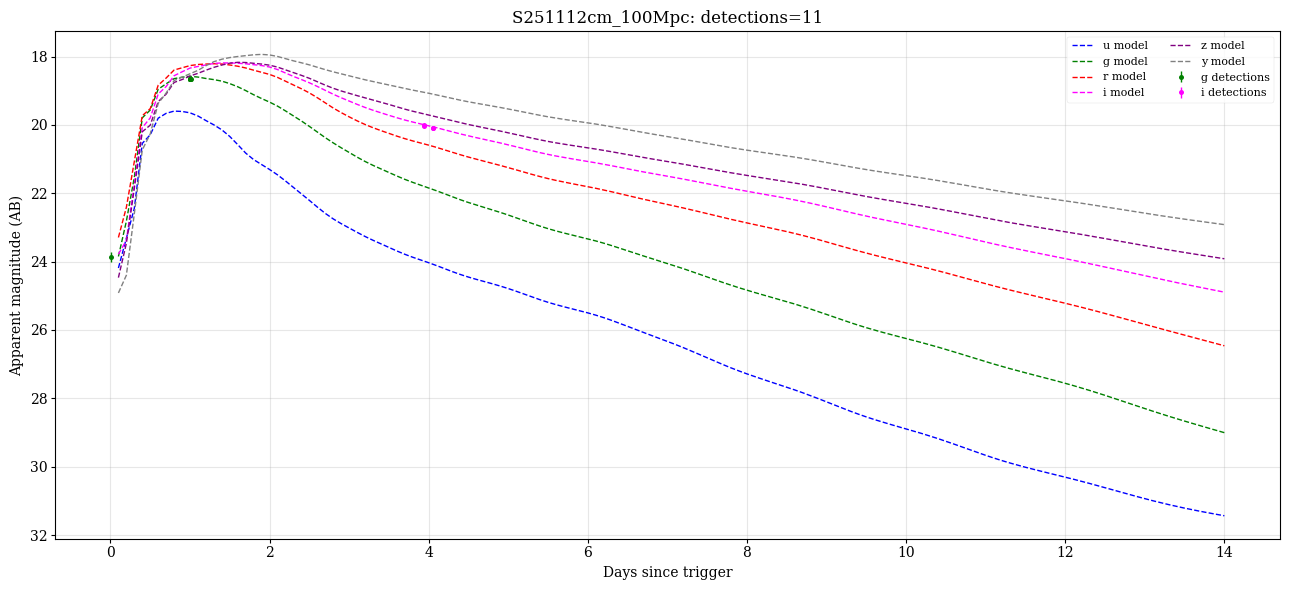

Success: reached 11 detections on attempt 1

Saved outputs:
  observations: /Users/np699/Downloads/RubinToOworkshop/2026_Berkeley/Rubin_ToO_workshop/outputs/S251112cm_100Mpc_observe.csv
  truth curves: /Users/np699/Downloads/RubinToOworkshop/2026_Berkeley/Rubin_ToO_workshop/outputs/S251112cm_100Mpc_true.csv
  plot: /Users/np699/Downloads/RubinToOworkshop/2026_Berkeley/Rubin_ToO_workshop/outputs/S251112cm_100Mpc.png


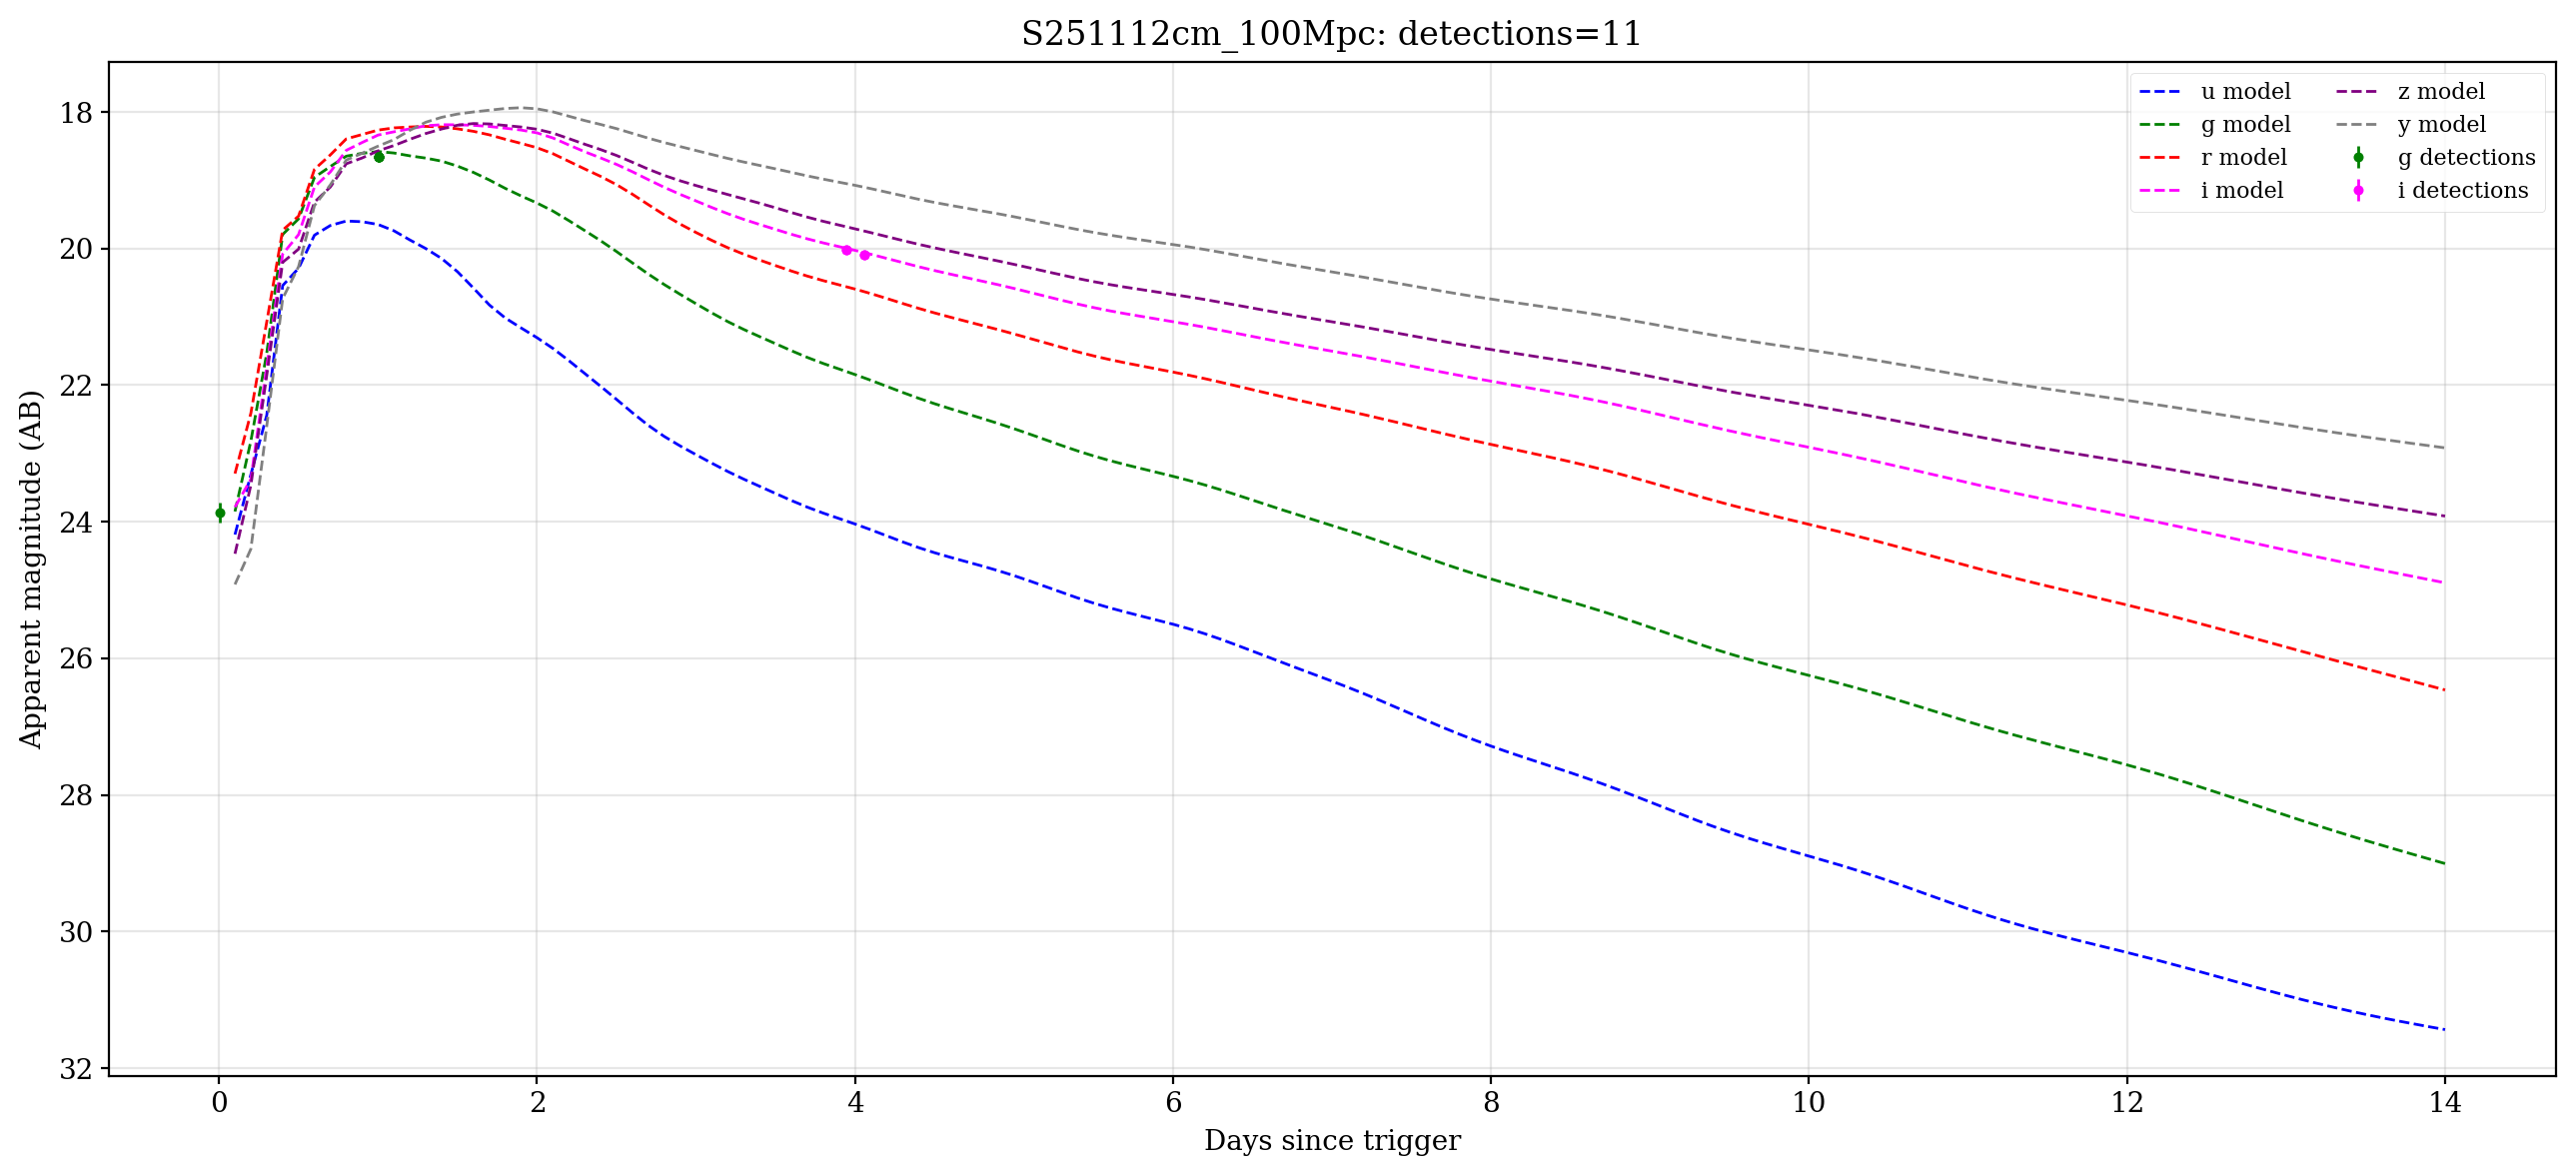

{'attempt': 1,
 'distance_mpc': 100,
 'selected_visit_count': 23,
 't0_sim_mjd': 60991.20126347534,
 'result': {'obs_csv': '/Users/np699/Downloads/RubinToOworkshop/2026_Berkeley/Rubin_ToO_workshop/outputs/S251112cm_100Mpc_observe.csv',
  'true_csv': '/Users/np699/Downloads/RubinToOworkshop/2026_Berkeley/Rubin_ToO_workshop/outputs/S251112cm_100Mpc_true.csv',
  'plot_png': '/Users/np699/Downloads/RubinToOworkshop/2026_Berkeley/Rubin_ToO_workshop/outputs/S251112cm_100Mpc.png',
  'n_obs_points': 11,
  'n_detections': 11,
  'dt_shift': 0.0,
  't0_used': 60991.20126347534,
  'attempt_meta': {'attempt': 1,
   't0_sim_mjd': 60991.20126347534,
   'ndet_window': 11,
   'event_elapsed_sec': 3.202}}}

In [8]:
result_100 = run_single_event(100, label_suffix="_100Mpc")
result_100


## 6. Inspect the Saved Observation Table

The saved CSV is the file you would hand to downstream exercises. It separates detections from limits with the `is_detection` column.


In [9]:
if result_100 is not None:
    obs_100 = pd.read_csv(result_100["result"]["obs_csv"])
    display(obs_100.head(10))
    display(obs_100.groupby(["filter", "is_detection"]).size().rename("count").reset_index())


,source_id,time,filter,snr,is_detection,mag,magerr,mag_lim
0,S251112cm_100Mpc,0.006962,g,7.192886,1,23.863632,0.150983,NaN
1,S251112cm_100Mpc,1.003622,g,1125.265783,1,18.655820,0.000965,NaN
2,S251112cm_100Mpc,1.004081,g,1232.519550,1,18.655512,0.000881,NaN
3,S251112cm_100Mpc,1.004550,g,1237.941802,1,18.656813,0.000877,NaN
4,S251112cm_100Mpc,1.005011,g,1234.948584,1,18.656795,0.000879,NaN
5,S251112cm_100Mpc,1.005472,g,1222.709766,1,18.658057,0.000888,NaN
6,S251112cm_100Mpc,1.006851,g,1268.500378,1,18.656155,0.000856,NaN
7,S251112cm_100Mpc,3.945083,i,165.922422,1,20.015879,0.006545,NaN
8,S251112cm_100Mpc,3.945549,i,182.400212,1,20.023914,0.005954,NaN
9,S251112cm_100Mpc,4.057341,i,88.295381,1,20.092578,0.012300,NaN


,filter,is_detection,count
0,g,1,7
1,i,1,4


## 7. Try a Larger Distance

Now move the same event to 200 Mpc. This keeps the sky position and observing sequence fixed, so the main difference is the intrinsic faintness of the source.


Injection parameters
  ra = 0.0
  dec = -0.52
  distance = 200.000 Mpc
  mej_dyn = 0.0134
  mej_disk = 0.0897
  phi = 45.000
  costheta_obs = 1.000000
  redshift = 0.045145

Rows before sky mask: 2,701
Rows after 1.75 deg sky mask: 23
Filters before cleanup: ['g_6', 'i_39']
Rows after keeping ugrizy: 23
Filters after cleanup: ['g', 'i']


,ID,RA,dec,mjd,flush_by_mjd,exptime,band,filter,rotSkyPos,rotSkyPos_desired,...,moonRA,moonDec,moonDist,solarElong,moonPhase,cummTelAz,observation_reason,science_program,cloud_extinction,note
15,15,0.004778,-0.548497,60991.208225,60993.166667,30.0,g,g,0.511184,0.0,...,2.504195,0.307020,2.513161,1.978630,49.780902,-1.842338,too_GW_case_B_C_0_i2,BLOCK-407,0.0,"ToO, GW_case_B_C, g, 0, i2, 5120"
17,17,6.260321,-0.539983,60991.209152,60993.083333,30.0,g,g,0.529602,0.0,...,2.504396,0.306961,2.538309,1.965957,49.775046,-1.839133,too_GW_case_B_C_0_i1,BLOCK-407,0.0,"ToO, GW_case_B_C, g, 0, i1, 3389"
18,18,6.260979,-0.536535,60991.209608,60993.166667,30.0,g,g,0.533221,0.0,...,2.504495,0.306932,2.538680,1.968570,49.772172,-1.834526,too_GW_case_B_C_0_i2,BLOCK-407,0.0,"ToO, GW_case_B_C, g, 0, i2, 5961"
19,19,6.264658,-0.531509,60991.210067,60993.000000,30.0,g,g,0.537180,0.0,...,2.504594,0.306903,2.536876,1.974196,49.769281,-1.827012,too_GW_case_B_C_0_i0,BLOCK-407,0.0,"ToO, GW_case_B_C, g, 0, i0, 838"
20,20,6.255497,-0.530238,60991.210526,60993.166667,30.0,g,g,0.541962,0.0,...,2.504693,0.306874,2.544921,1.968860,49.766391,-1.828168,too_GW_case_B_C_0_i2,BLOCK-407,0.0,"ToO, GW_case_B_C, g, 0, i2, 5958"


ObsTable ready with 23 rows
Time bounds: [60991.20822530045, 60995.259070850036]


Simulating:   0%|          | 0/1 [00:00<?, ?obj/s]

Simulating: 100%|██████████| 1/1 [00:00<00:00, 43.07obj/s]

Attempt 1: ndet = 10


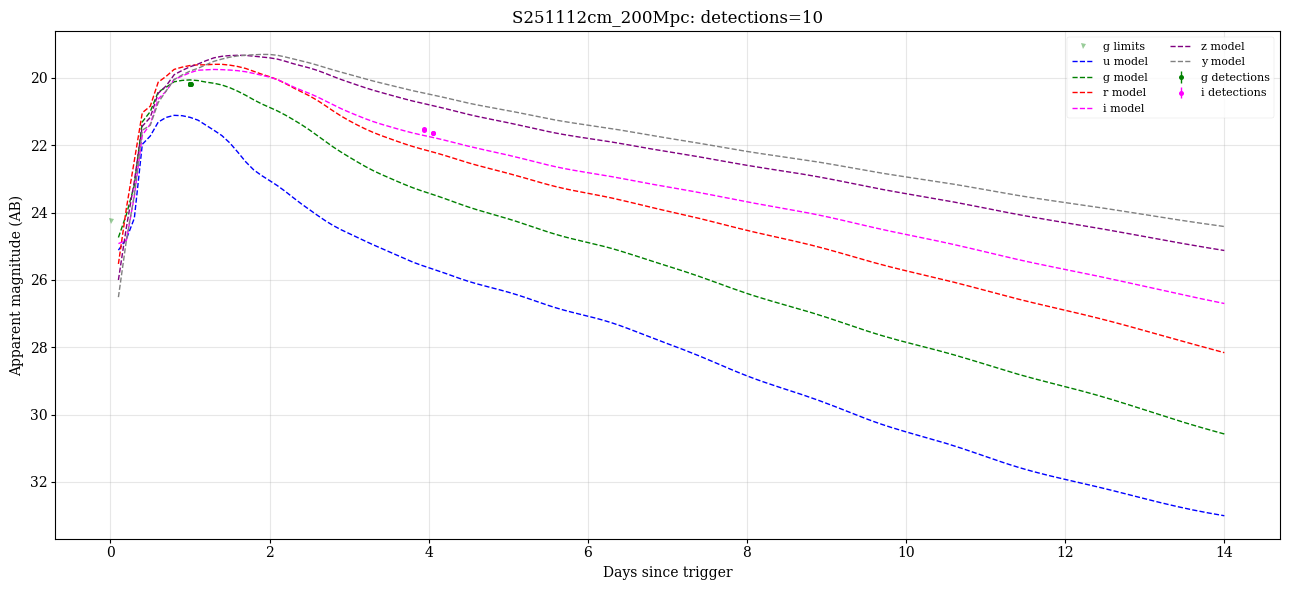

Success: reached 10 detections on attempt 1

Saved outputs:
  observations: /Users/np699/Downloads/RubinToOworkshop/2026_Berkeley/Rubin_ToO_workshop/outputs/S251112cm_200Mpc_observe.csv
  truth curves: /Users/np699/Downloads/RubinToOworkshop/2026_Berkeley/Rubin_ToO_workshop/outputs/S251112cm_200Mpc_true.csv
  plot: /Users/np699/Downloads/RubinToOworkshop/2026_Berkeley/Rubin_ToO_workshop/outputs/S251112cm_200Mpc.png


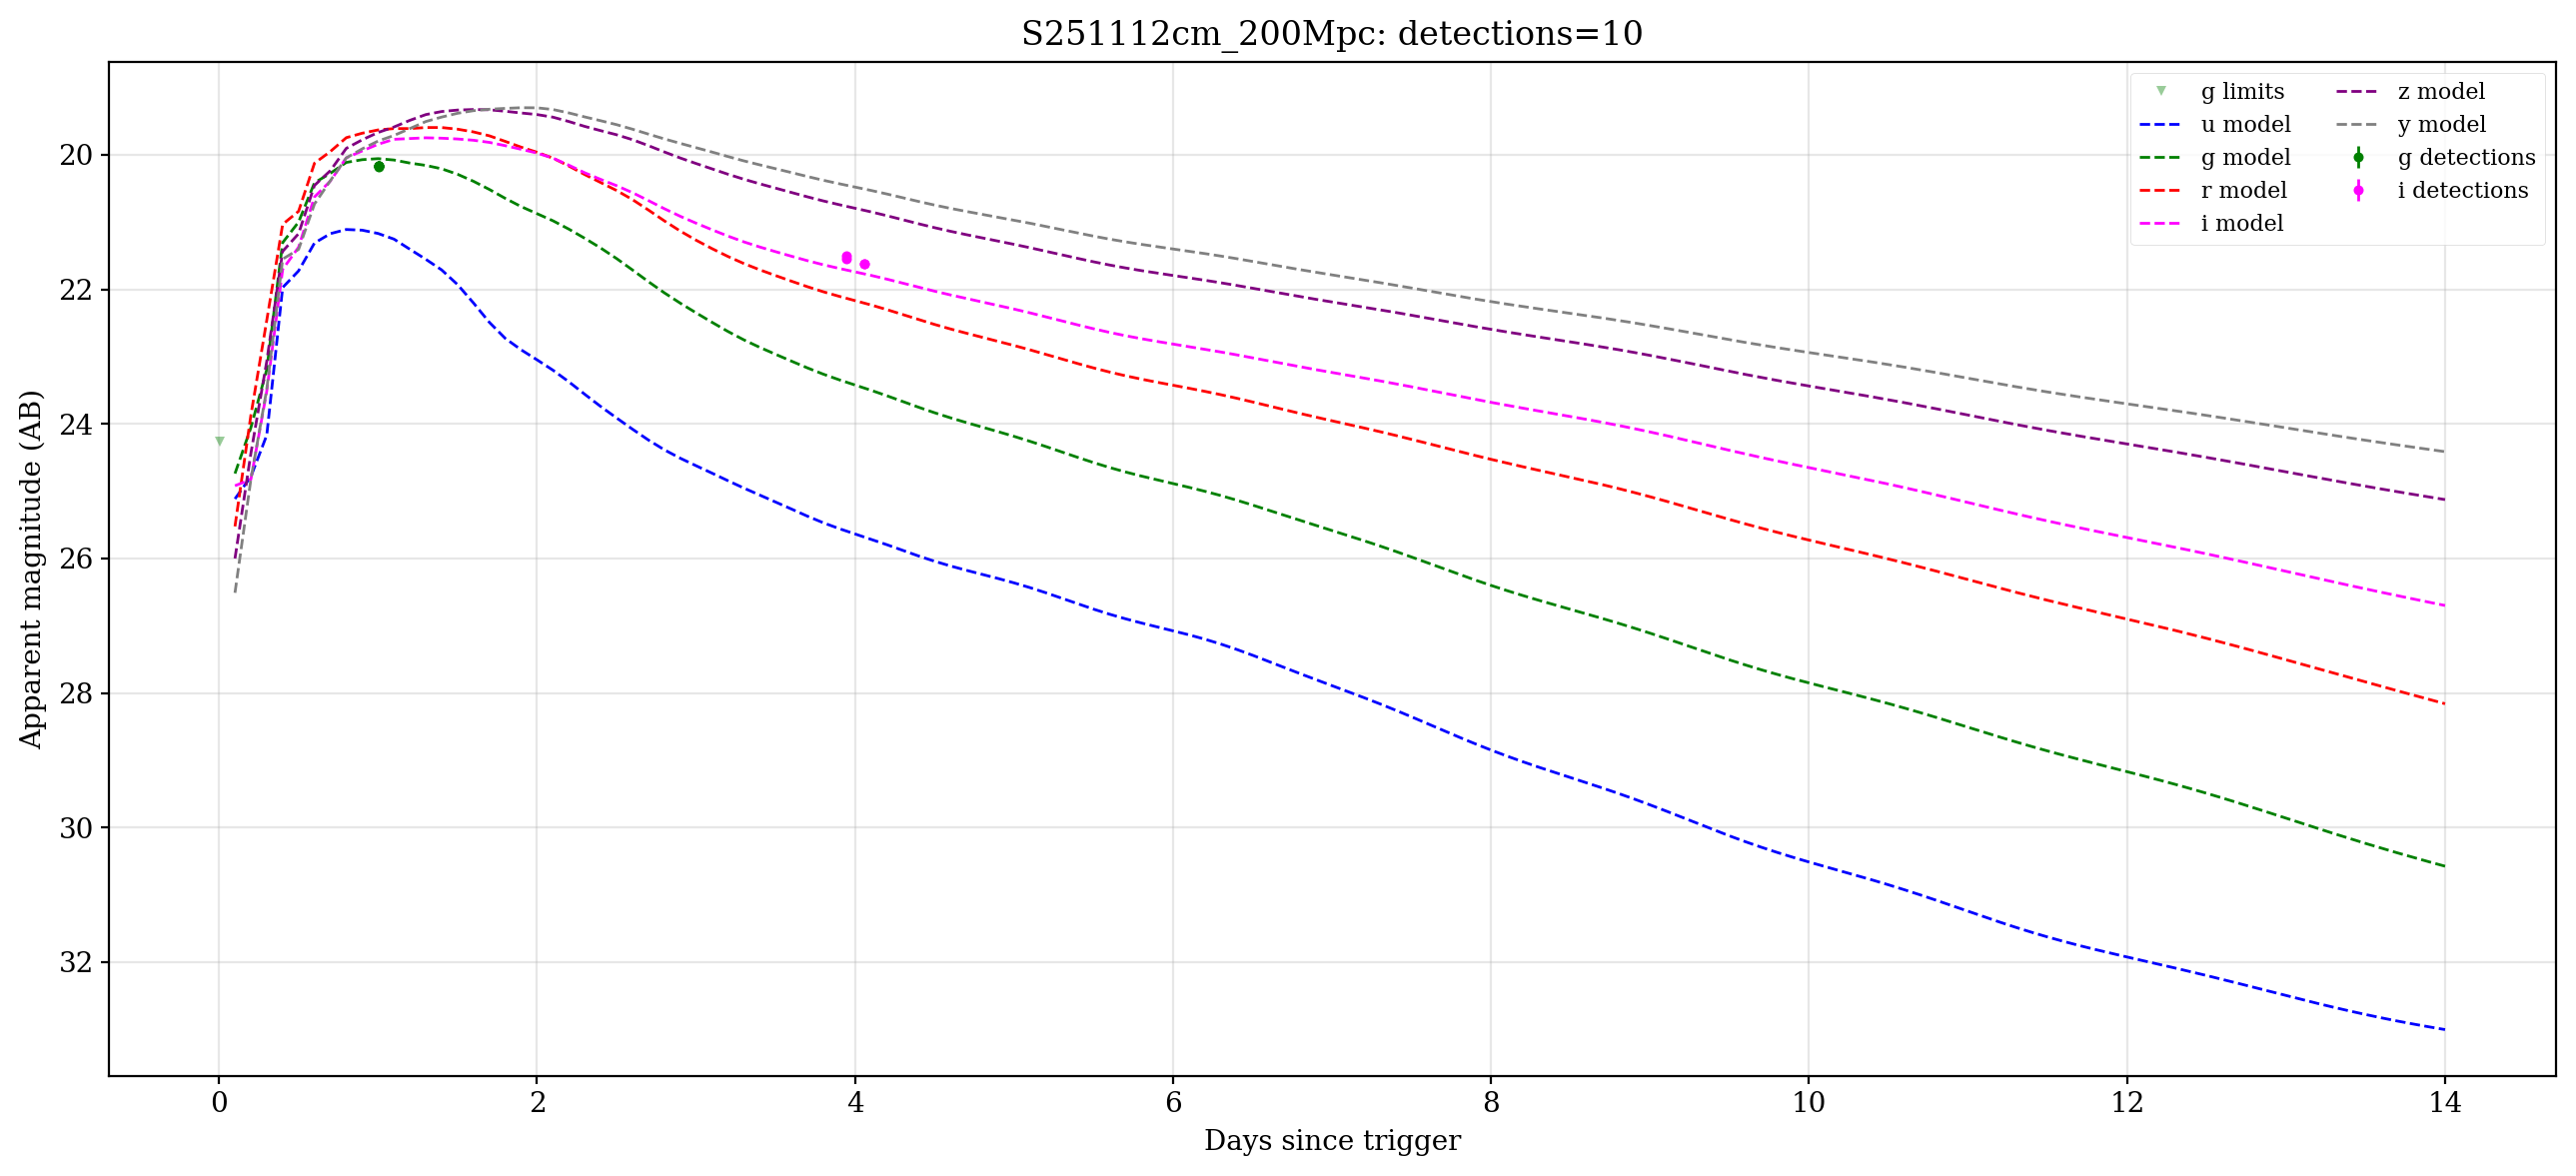

{'attempt': 1,
 'distance_mpc': 200,
 'selected_visit_count': 23,
 't0_sim_mjd': 60991.20126347534,
 'result': {'obs_csv': '/Users/np699/Downloads/RubinToOworkshop/2026_Berkeley/Rubin_ToO_workshop/outputs/S251112cm_200Mpc_observe.csv',
  'true_csv': '/Users/np699/Downloads/RubinToOworkshop/2026_Berkeley/Rubin_ToO_workshop/outputs/S251112cm_200Mpc_true.csv',
  'plot_png': '/Users/np699/Downloads/RubinToOworkshop/2026_Berkeley/Rubin_ToO_workshop/outputs/S251112cm_200Mpc.png',
  'n_obs_points': 11,
  'n_detections': 10,
  'dt_shift': 0.0,
  't0_used': 60991.20126347534,
  'attempt_meta': {'attempt': 1,
   't0_sim_mjd': 60991.20126347534,
   'ndet_window': 10,
   'event_elapsed_sec': 0.031}}}

In [10]:
result_200 = run_single_event(200, label_suffix="_200Mpc")
result_200


## 8. Compare the Two Runs

Use this compact summary to start a discussion about follow-up strategy: cadence, filter choice, limiting magnitude, and distance.


In [12]:
summary_rows = []
for label, result in [("100 Mpc", result_100), ("200 Mpc", result_200)]:
    if result is None:
        summary_rows.append({"case": label, "detections": np.nan, "obs_points": np.nan, "plot": None})
    else:
        summary_rows.append({
            "case": label,
            "detections": result["result"]["n_detections"],
            "obs_points": result["result"]["n_obs_points"],
            "selected_visits": result["selected_visit_count"],
            "plot": result["result"]["plot_png"],
        })

summary = pd.DataFrame(summary_rows)
display(summary)


,case,detections,obs_points,selected_visits,plot
0,100 Mpc,11,11,23,/Users/np699/Downloads/RubinToOworkshop/2026_B...
1,200 Mpc,10,11,23,/Users/np699/Downloads/RubinToOworkshop/2026_B...
